In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns, sklearn, sklearn.metrics

In [2]:
df_pools_ = pd.read_csv('mgen_pools.tsv', sep='\t')
df_pools_

,name,group,pool_nchains,pool_size,chain_ids,fraction_disordered,has_clash,iptm,ptm,ranking_score,...,model3_chain_ptm,model4_fraction_disordered,model4_has_clash,model4_iptm,model4_ptm,model4_ranking_score,model4_chain_iptm,model4_chain_pair_iptm,model4_chain_pair_pae_min,model4_chain_ptm
0,pairs_000366f,pairs,2,441,aac71319.1_aac71429.1,0.12,0.0,0.13,0.49,0.27,...,"[0.83, 0.37]",0.06,0.0,0.12,0.50,0.23,"[0.12, 0.12]","[[0.82, 0.12], [0.12, 0.37]]","[[0.76, 21.04], [18.58, 0.76]]","[0.82, 0.37]"
1,pairs_0046771,pairs,2,1054,aac71390.1_aac71413.1,0.02,0.0,0.18,0.61,0.27,...,"[0.87, 0.73]",0.02,0.0,0.18,0.61,0.27,"[0.18, 0.18]","[[0.86, 0.18], [0.18, 0.73]]","[[0.76, 23.24], [24.92, 0.76]]","[0.86, 0.73]"
2,pairs_0061302,pairs,2,722,aac71406.1_aac71579.1,0.00,0.0,0.31,0.63,0.37,...,"[0.68, 0.8]",0.00,0.0,0.30,0.64,0.37,"[0.3, 0.3]","[[0.7, 0.3], [0.3, 0.8]]","[[0.76, 13.28], [15.66, 0.76]]","[0.7, 0.8]"
3,pairs_0076b25,pairs,2,237,aac71377.1_aac71393.1,0.51,0.0,0.11,0.31,0.40,...,"[0.33, 0.54]",0.51,0.0,0.11,0.31,0.40,"[0.11, 0.11]","[[0.34, 0.11], [0.11, 0.53]]","[[0.76, 21.0], [21.46, 0.76]]","[0.34, 0.53]"
4,pairs_007a3ac,pairs,2,636,aac71301.1_aac71619.1,0.00,0.0,0.11,0.66,0.22,...,"[0.88, 0.87]",0.00,0.0,0.10,0.66,0.21,"[0.1, 0.1]","[[0.88, 0.1], [0.1, 0.87]]","[[0.76, 27.21], [27.36, 0.76]]","[0.88, 0.87]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6226,pools_5k_fcb9a7c,pools_5k,18,5072,aac71270.1_aac71277.1_aac71354.1_aac71363.1_aa...,0.09,0.0,0.29,0.37,0.35,...,"[0.42, 0.66, 0.75, 0.67, 0.68, 0.64, 0.56, 0.7...",0.08,0.0,0.29,0.37,0.34,"[0.07, 0.07, 0.08, 0.06, 0.07, 0.05, 0.05, 0.0...","[[0.41, 0.07, 0.09, 0.07, 0.07, 0.05, 0.06, 0....","[[0.76, 31.06, 27.37, 31.47, 31.13, 31.23, 31....","[0.41, 0.66, 0.75, 0.67, 0.68, 0.64, 0.55, 0.7..."
6227,pools_5k_fd16d98,pools_5k,17,5036,aac71274.1_aac71276.1_aac71313.1_aac71314.1_aa...,0.06,0.0,0.29,0.35,0.34,...,"[0.47, 0.63, 0.43, 0.4, 0.6, 0.68, 0.57, 0.59,...",0.06,0.0,0.29,0.35,0.33,"[0.06, 0.06, 0.08, 0.1, 0.07, 0.05, 0.05, 0.07...","[[0.47, 0.05, 0.07, 0.09, 0.04, 0.04, 0.04, 0....","[[0.76, 30.61, 31.45, 31.42, 30.61, 30.61, 31....","[0.47, 0.64, 0.41, 0.39, 0.6, 0.69, 0.57, 0.56..."
6228,pools_5k_fd184bc,pools_5k,17,5011,aac71268.1_aac71269.1_aac71306.1_aac71313.1_aa...,0.06,0.0,0.32,0.35,0.35,...,"[0.73, 0.78, 0.73, 0.37, 0.39, 0.63, 0.57, 0.6...",0.06,0.0,0.32,0.35,0.35,"[0.06, 0.09, 0.06, 0.09, 0.11, 0.12, 0.1, 0.09...","[[0.73, 0.08, 0.04, 0.06, 0.08, 0.07, 0.03, 0....","[[0.76, 31.0, 30.98, 31.26, 31.45, 28.51, 30.5...","[0.73, 0.78, 0.72, 0.37, 0.39, 0.66, 0.56, 0.6..."
6229,pools_5k_fd8e615,pools_5k,18,5113,aac71271.1_aac71274.1_aac71276.1_aac71304.1_aa...,0.08,0.0,0.29,0.36,0.34,...,"[0.24, 0.49, 0.62, 0.56, 0.65, 0.58, 0.63, 0.5...",0.08,0.0,0.29,0.36,0.34,"[0.06, 0.06, 0.06, 0.08, 0.08, 0.05, 0.05, 0.0...","[[0.24, 0.04, 0.04, 0.07, 0.07, 0.03, 0.03, 0....","[[0.76, 31.37, 31.17, 28.85, 29.84, 31.26, 31....","[0.24, 0.47, 0.62, 0.54, 0.65, 0.58, 0.62, 0.5..."


group
pairs       4560
pools_2k     802
pools_3k     354
pools_4k     267
pools_5k     248
Name: count, dtype: int64


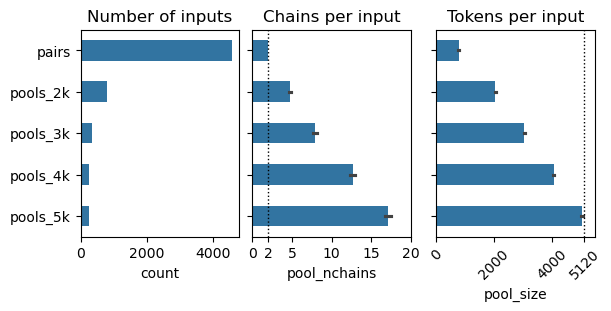

In [3]:
width_ = .5
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(6, 3), constrained_layout=True, sharey=True)
plt.subplot(1, 3, 1)
plt.title(f'Number of inputs')
sns.barplot(df_pools_['group'].value_counts().reset_index(), x='count', y='group', width=width_)
plt.gca().set_ylabel('')
print(df_pools_['group'].value_counts())

plt.subplot(1, 3, 2)
plt.title(f'Chains per input')
sns.barplot(df_pools_, x='pool_nchains', y='group', orient='h', width=width_)
plt.gca().set_ylabel('')
plt.gca().set_xticks([0, 2, 5, 10, 15, 20])
plt.axvline(2, color='k', linewidth=1, linestyle='dotted')

plt.subplot(1, 3, 3)
plt.title(f'Tokens per input')
sns.barplot(df_pools_, x='pool_size', y='group', orient='h', width=width_)
plt.gca().set_xticks([0, 2000, 4000, 5120])
plt.gca().set_xlim([0, 5500])
plt.gca().tick_params(axis='x', rotation=45)
plt.axvline(5120, color='k', linewidth=1, linestyle='dotted')
plt.gca().set_ylabel('')
plt.savefig('mgen_pools.svg', bbox_inches='tight', transparent=True)